In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Setup ---
# Load the master data file
# Make sure this notebook is in the 'analysis' directory
try:
    df = pd.read_csv("master_results_with_difficulty.csv")
except FileNotFoundError:
    print("master_results.csv not found. Please run create_master_summary.py first.")

# Set a nice style for the plots
sns.set_theme(style="whitegrid", context="talk")

print("Data loaded successfully. Here's a preview:")
print(f"Total results loaded: {len(df)}")
df.head(40)

Data loaded successfully. Here's a preview:
Total results loaded: 30166


,item_id,dataset,strategy,compute_budget,n_samples,answer_em,answer_f1,answer_precision,answer_recall,support_f1,...,accuracy,error,difficulty_score_overall,difficulty_bin_overall,difficulty_score_per_dataset,difficulty_bin_per_dataset,difficulty_score_by_strategy,difficulty_bin_by_strategy,difficulty_score_per_dataset_strategy,difficulty_bin_per_dataset_strategy
0,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,4096,4,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
1,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,4096,8,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
2,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,4096,16,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
3,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,4096,32,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
4,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,8192,4,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
5,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,8192,8,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
6,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,8192,16,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
7,00efceca0bb011ebab90acde48001122,2wikimultihopqa,parallel,8192,32,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
8,00efceca0bb011ebab90acde48001122,2wikimultihopqa,sequential,4096,4,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy
9,00efceca0bb011ebab90acde48001122,2wikimultihopqa,sequential,4096,8,0.0,0.666667,1.0,0.5,0.0,...,0.666667,NaN,0.666667,easy,0.666667,easy,0.666667,easy,0.666667,easy


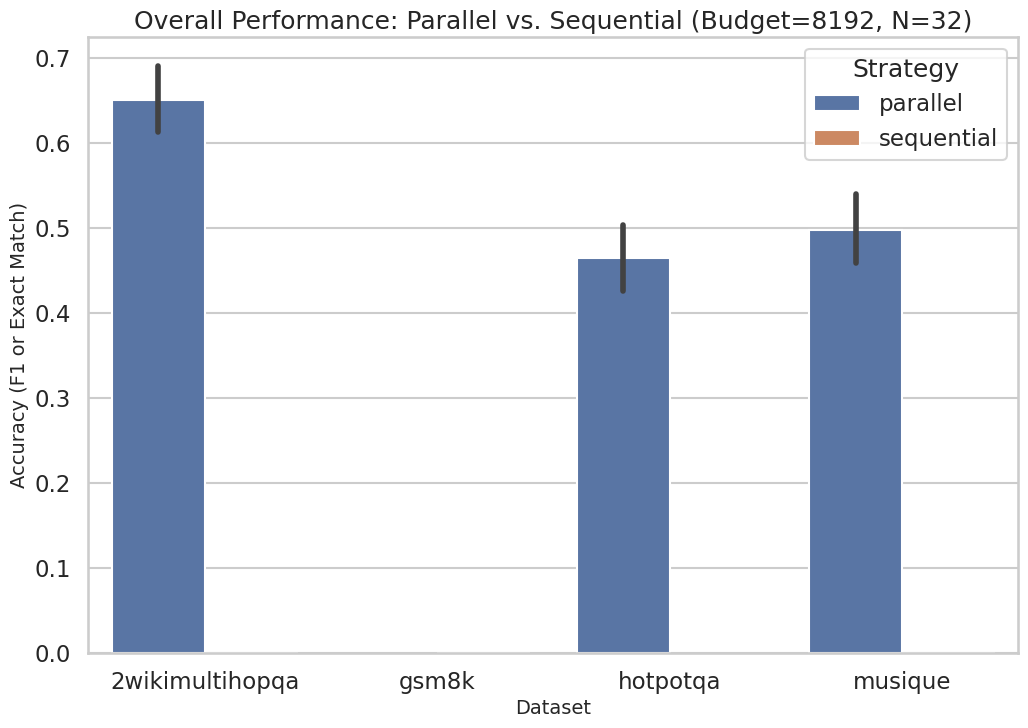

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

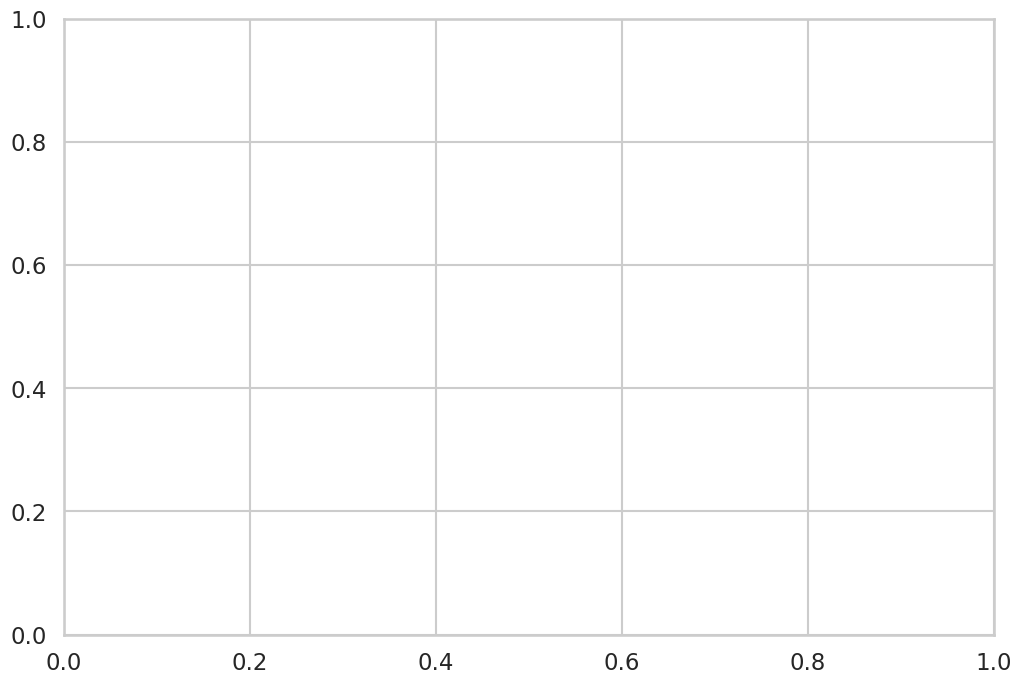

In [15]:
# Filter for the highest compute budget and highest n_samples to see the "best effort"
df_best_effort = df[
    (df['compute_budget'] == df['compute_budget'].max()) &
    (df['n_samples'] == df['n_samples'].max())
]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_best_effort,
    x="dataset",
    y="accuracy",
    hue="strategy",
    hue_order=['parallel', 'sequential']
)
ax.set_title(f"Overall Performance: Parallel vs. Sequential (Budget={df['compute_budget'].max()}, N={df['n_samples'].max()})", fontsize=18)
ax.set_xlabel("Dataset", fontsize=14)
ax.set_ylabel("Accuracy (F1 or Exact Match)", fontsize=14)
plt.legend(title="Strategy")
plt.show()



# df_best_effort = df[
#     (df['compute_budget'] == df['compute_budget'].min()) &
#     (df['n_samples'] == df['n_samples'].max())
# ]

# plt.figure(figsize=(12, 8))
# ax = sns.barplot(
#     data=df_best_effort,
#     x="dataset",
#     y="accuracy",
#     hue="strategy",
#     hue_order=['parallel', 'sequential']
# )
# ax.set_title(f"Overall Performance: Parallel vs. Sequential (Budget={df['compute_budget'].min()}, N={df['n_samples'].max()})", fontsize=18)
# ax.set_xlabel("Dataset", fontsize=14)
# ax.set_ylabel("Accuracy (F1 or Exact Match)", fontsize=14)
# plt.legend(title="Strategy")
# plt.show()


--- Plot 1: Performance vs. N-Samples Allocation ---


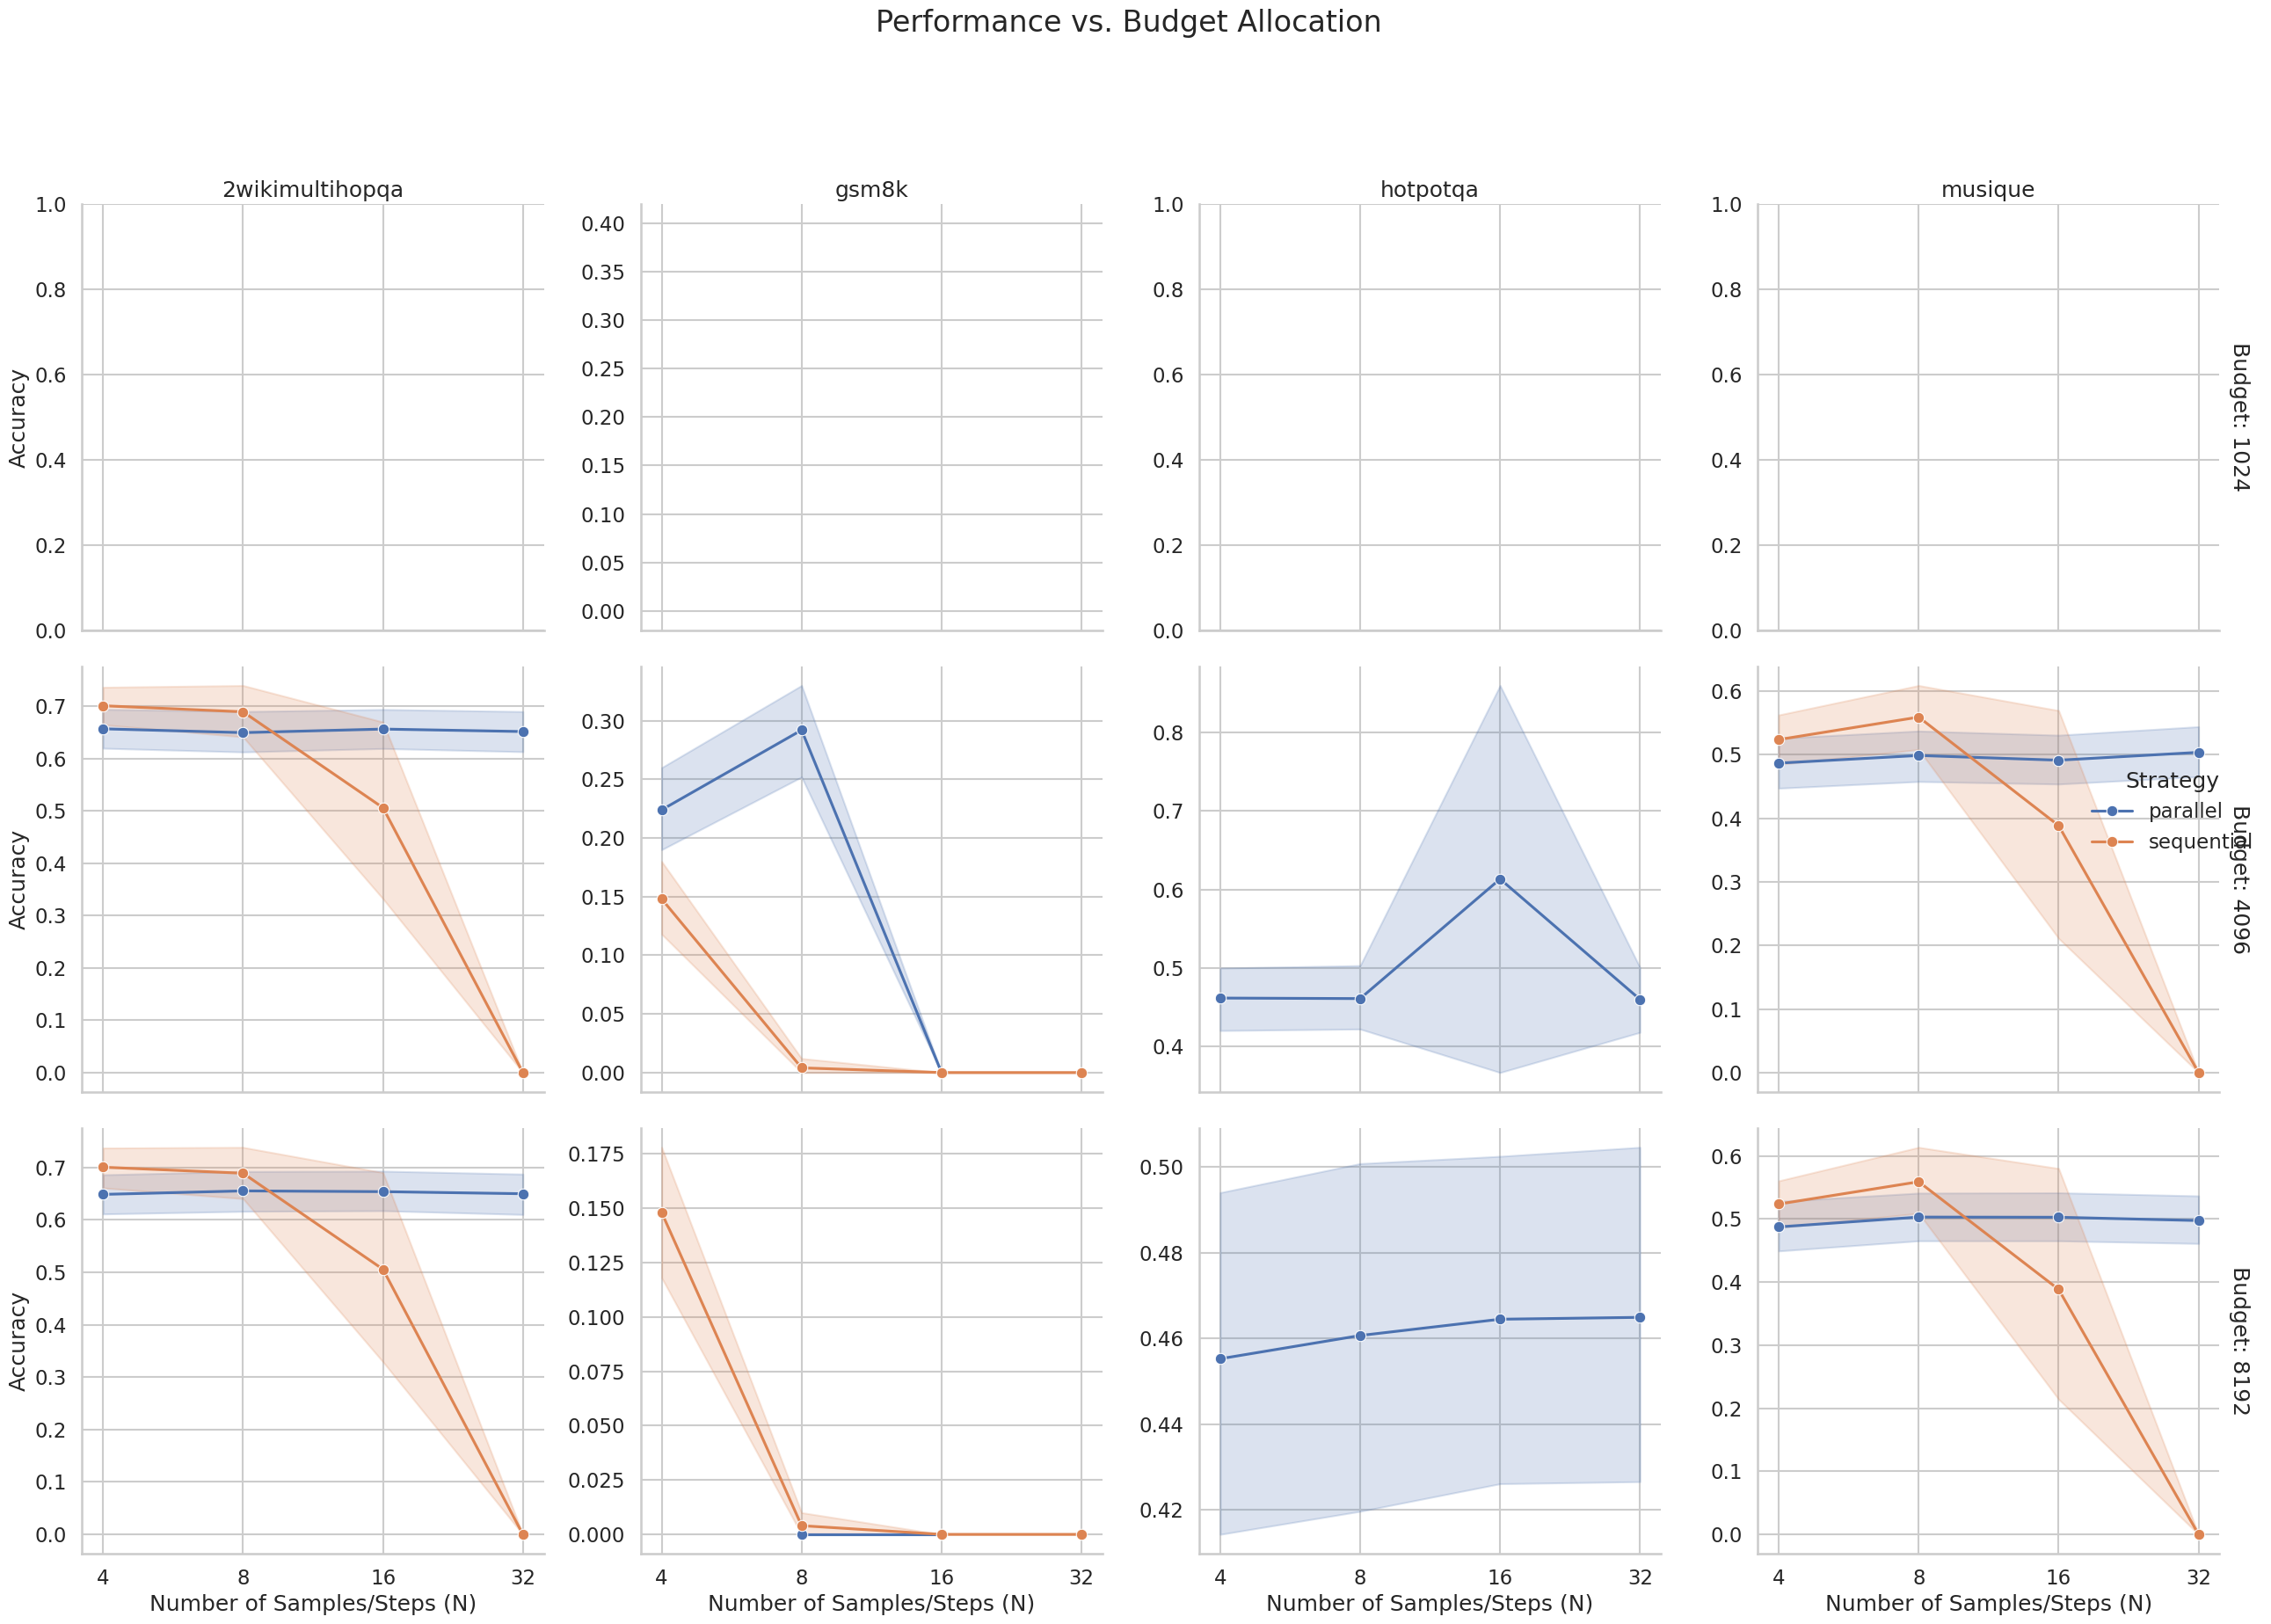

In [6]:
# This plot shows how performance changes as we use more samples/steps (N)
# for a fixed total compute budget.
print("--- Plot 1: Performance vs. N-Samples Allocation ---")

g = sns.FacetGrid(
    df, 
    col="dataset", 
    row="compute_budget", 
    hue="strategy",
    height=6,
    margin_titles=True,
    hue_order=['parallel', 'sequential'],
    sharey=False # Allow y-axis to be different for each row
)

g.map(sns.lineplot, "n_samples", "accuracy", marker="o")
g.add_legend(title="Strategy")
g.set_axis_labels("Number of Samples/Steps (N)", "Accuracy")
g.set_titles(col_template="{col_name}", row_template="Budget: {row_name}")
g.fig.suptitle("Performance vs. Budget Allocation", fontsize=24, y=1.03)

# Use a log scale for the x-axis, like the paper
for ax in g.axes.flat:
    ax.set_xscale('log', base=2)
    ax.set_xticks([4, 8, 16, 32])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


--- Plot 4: Performance vs. Tokens Per Step ---


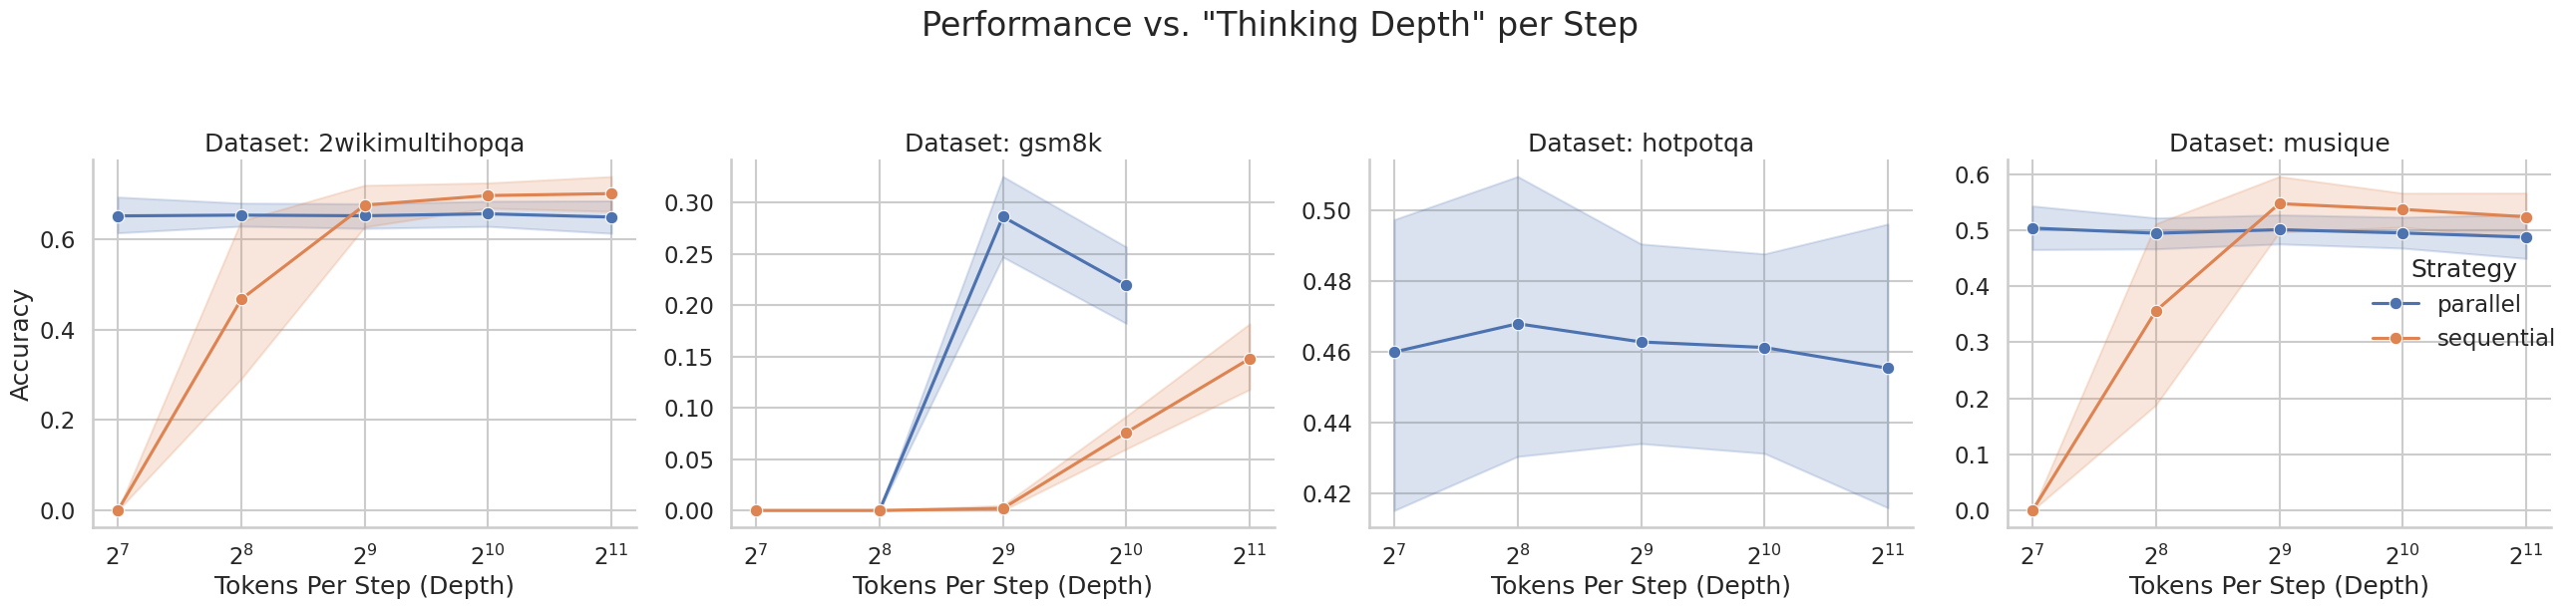

In [7]:
# Cell 5: Performance vs. "Thinking Depth" (Tokens per Step)
# This plot directly visualizes the trade-off between breadth (n_samples)
# and depth (tokens_per_step).

print("\n--- Plot 4: Performance vs. Tokens Per Step ---")

# First, we need to create this new metric in our DataFrame.
df['tokens_per_step'] = df['compute_budget'] / df['n_samples']

# Now, we create the plot
g = sns.FacetGrid(
    df,
    col="dataset",
    hue="strategy",
    height=6,
    margin_titles=True,
    hue_order=['parallel', 'sequential'],
    sharey=False
)

# We plot accuracy against the new 'tokens_per_step' metric.
# We can use the size of the marker to represent the number of samples (n_samples).
g.map(sns.lineplot, "tokens_per_step", "accuracy", marker="o")

g.add_legend(title="Strategy")
g.set_axis_labels("Tokens Per Step (Depth)", "Accuracy")
g.set_titles(col_template="Dataset: {col_name}")
g.fig.suptitle("Performance vs. \"Thinking Depth\" per Step", fontsize=24, y=1.03)

# The x-axis values might be spread out, so a log scale can be helpful here too.
for ax in g.axes.flat:
    ax.set_xscale('log', base=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

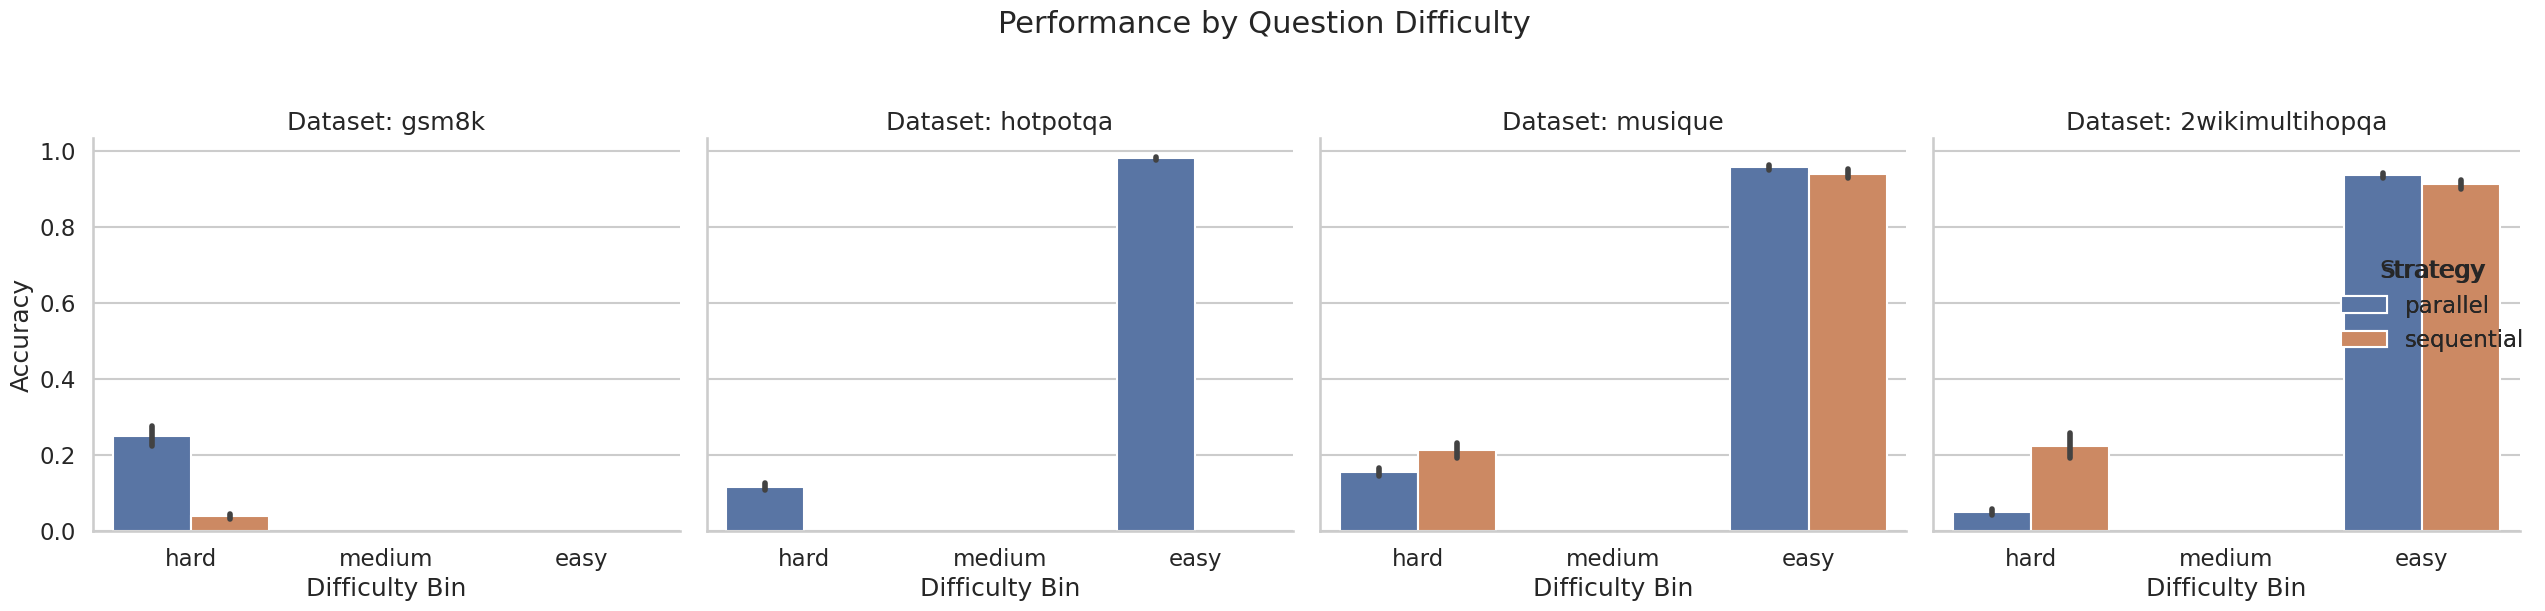

In [8]:
# You can choose which difficulty metric to use by changing the 'x' value
# Options: 'difficulty_bin_per_dataset' or 'difficulty_bin_overall'
DIFFICULTY_METRIC_TO_PLOT = 'difficulty_bin_per_dataset'


g = sns.catplot(
    data=df,
    x=DIFFICULTY_METRIC_TO_PLOT,
    y="accuracy",
    hue="strategy",
    col="dataset",
    kind="bar",
    height=6,
    aspect=0.9,
    order=['hard', 'medium', 'easy'],
    hue_order=['parallel', 'sequential'],
    col_order = ['gsm8k', 'hotpotqa', 'musique', '2wikimultihopqa'] # Control dataset order
)

g.fig.suptitle("Performance by Question Difficulty", fontsize=22, y=1.03)
g.set_axis_labels("Difficulty Bin", "Accuracy")
g.set_titles("Dataset: {col_name}")
g.add_legend(title="Strategy")
plt.tight_layout()
plt.show()


--- Plot 2: Performance by Question Difficulty ---


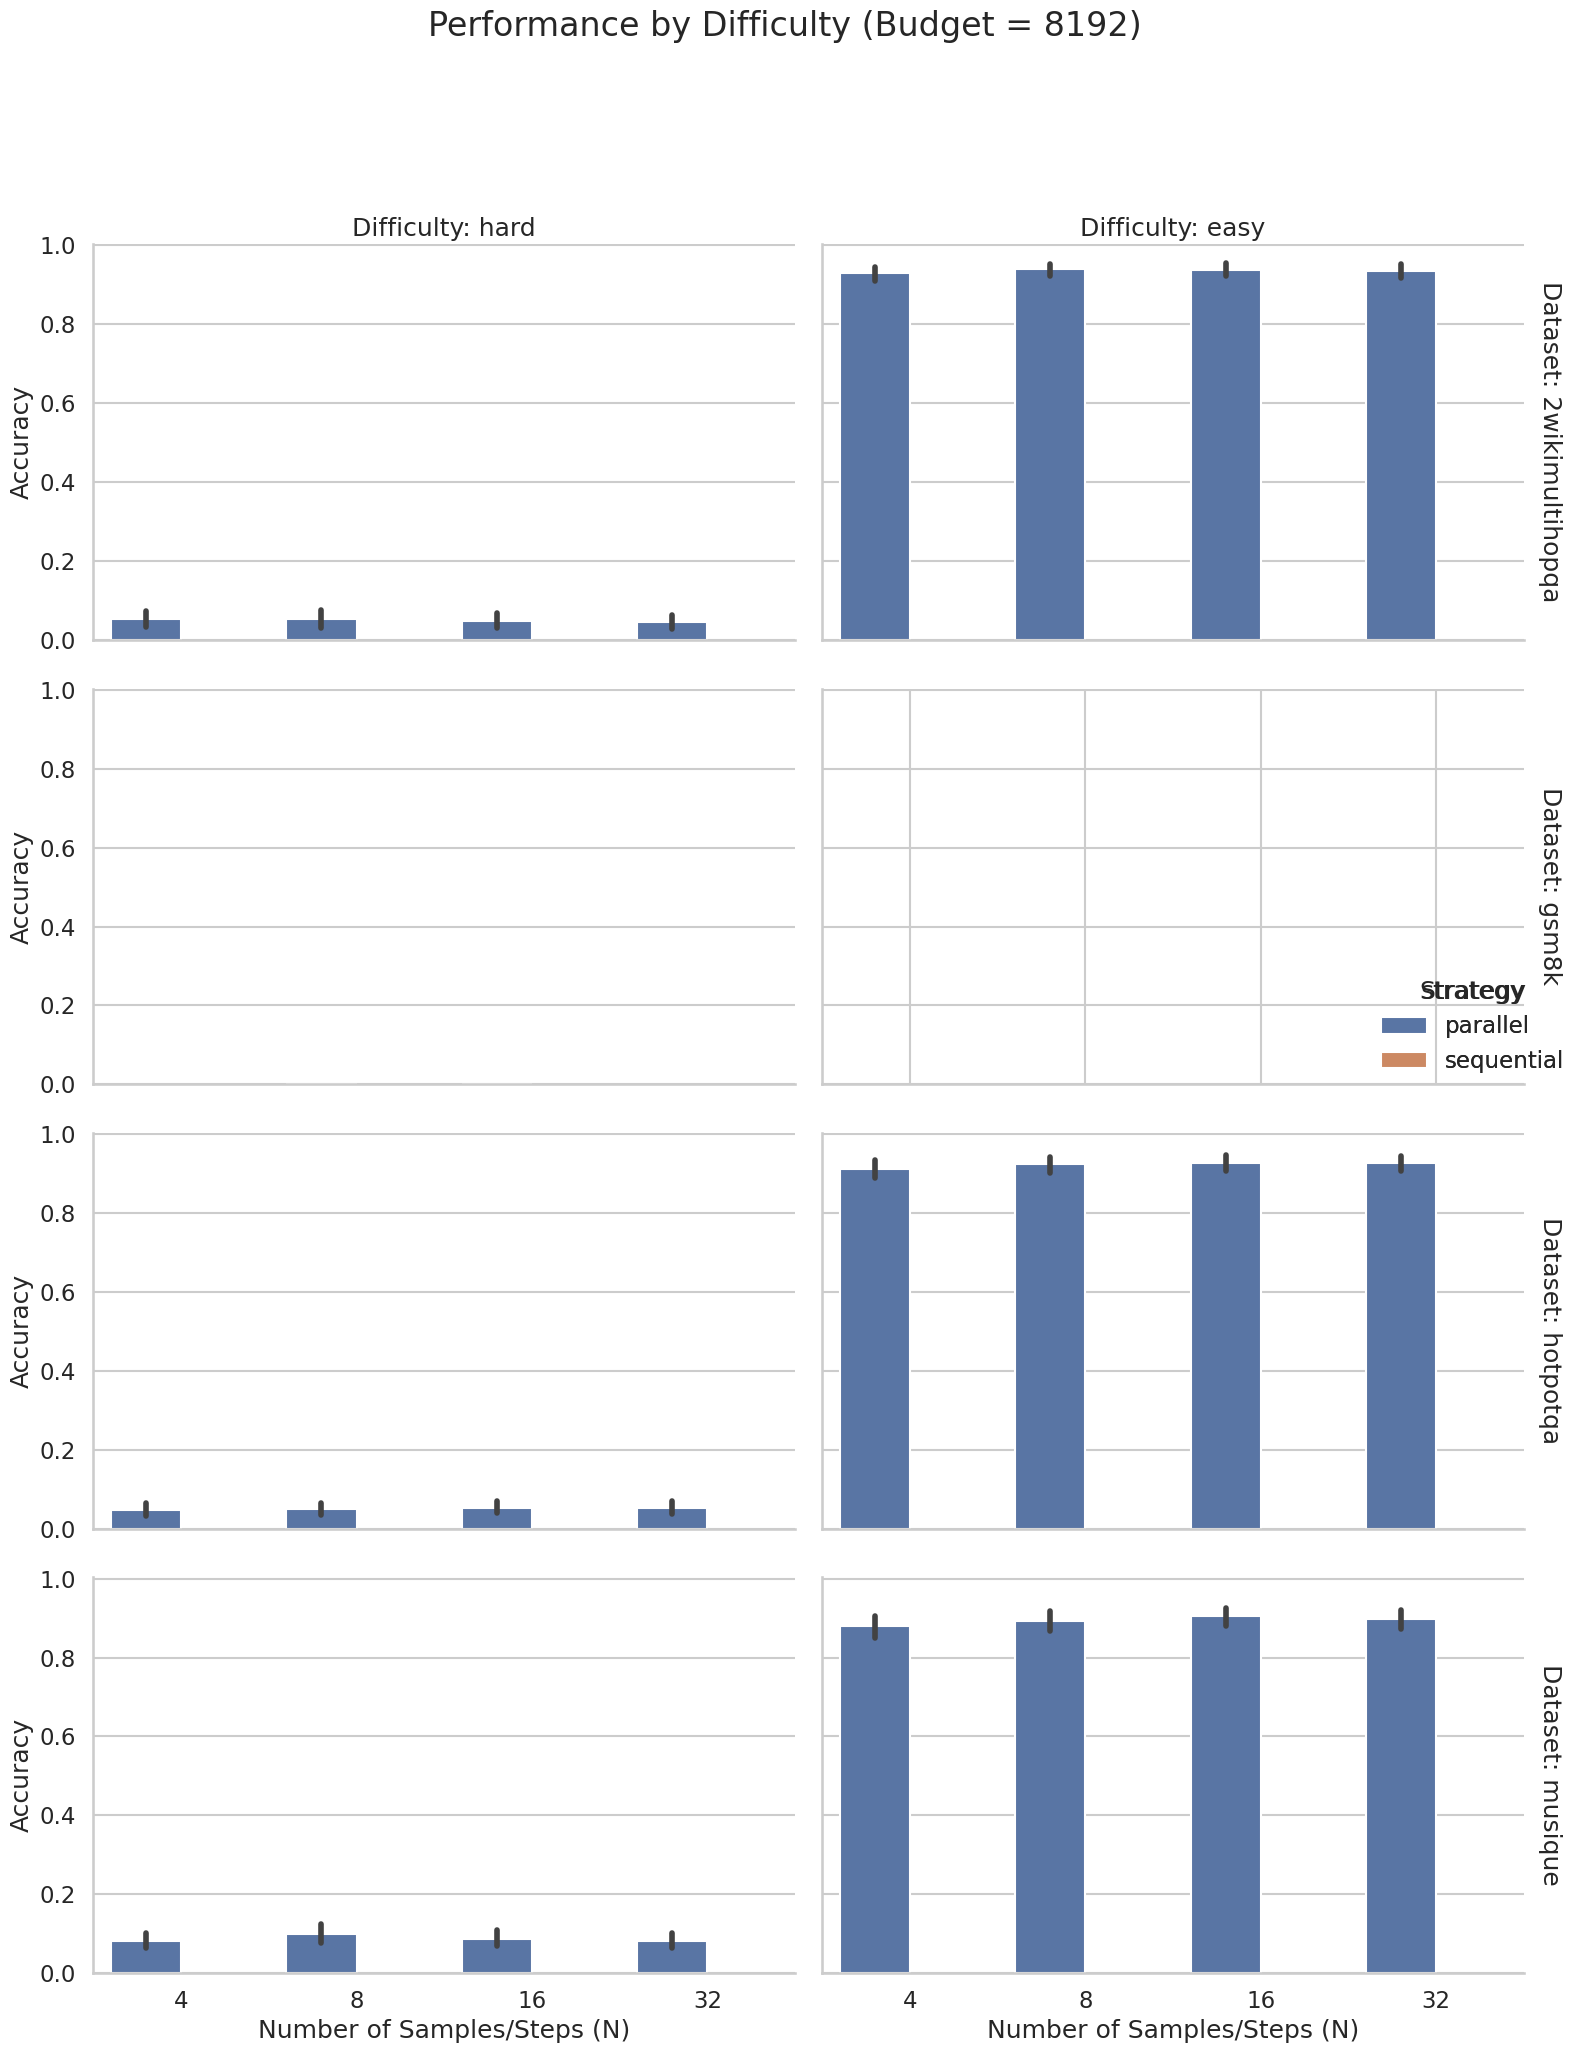

In [8]:
# This plot uses the 'difficulty_bin_per_dataset' column we created.
# It shows which strategy works best for easy vs. hard questions.
print("\n--- Plot 2: Performance by Question Difficulty ---")

# We can filter to a specific budget for a cleaner chart
# df_plot = df[df.compute_budget == 8192]
DIFFICULTY_METRIC_TO_PLOT = 'difficulty_bin_per_dataset'
g = sns.catplot(
    data=df_plot,
    x="n_samples",
    y="accuracy",
    hue="strategy",
    col=DIFFICULTY_METRIC_TO_PLOT, # <-- USING THE NEW COLUMN
    row="dataset",
    kind="bar",
    height=5,
    aspect=1.2,
    hue_order=['parallel', 'sequential'],
    col_order=['hard', 'easy'], # Control the order of columns
    margin_titles=True
)

g.fig.suptitle("Performance by Difficulty (Budget = 8192)", fontsize=24, y=1.03)
g.set_axis_labels("Number of Samples/Steps (N)", "Accuracy")
g.set_titles(col_template="Difficulty: {col_name}", row_template="Dataset: {row_name}")
g.add_legend(title="Strategy")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()